# Interactive Prototype

Goal: Create a functional MVP for field route planning and management.

Stages:
1. Region Input & Sub-Division
2. Automatic Target Search & Routing
3. Manual Adjustment
4. Select & Execute Plans

## Region Input & Sub-Division

- Get region outline
- Divide into work cells
- Tentative plan for depot locations
- 

### Dummy Region Shapefile

At this point, we do not actually have a shapefile of the target region. The following two Jupyter cells will generate one using the outline of the orthophoto we have created. 

Load this as the "shapefile" which will define our working region. 

In [1]:
region_image_path = '../input/IGNORE_Brewster-2024-all-orthophoto-UTM-32613.tif'
region_contour_shapefile = '../input/interactive_proto/region_contour.shp'
region_contour_geojson = '../input/interactive_proto/region_contour.geojson'


region_crs = 32613 # Use this everywhere for consistency
visualization_crs = 4326 # Use this when we need leaflet visualizations
simplification_tolerance = 5


In [2]:
import sys
import geopandas as gpd
from pathlib import Path
sys.path.append(str(Path.cwd().parent))

In [3]:
from plant_search.load_image import load_image
from plant_search.region_partition import extract_region_contour, simplify_polygon

# image, transform, bounds, image_crs = load_image(region_image_path)

# Get region contour, emulating shapefile input
region_contour_gpd = extract_region_contour(region_image_path)
contour_gdf_projected = region_contour_gpd.to_crs(epsg=region_crs)  # Example: UTM Zone 14N
region_contour = simplify_polygon(contour_gdf_projected.geometry.iloc[0], simplification_tolerance)
region_contour_gdf = gpd.GeoDataFrame({"geometry": [region_contour]}, crs=region_crs) # Convert to GDF
# region_contour_gdf = gpd.GeoDataFrame({"geometry": [region_contour]}) # Convert to GDF

# Save as shape file
region_contour_gdf.to_file(region_contour_shapefile, driver="ESRI Shapefile")

# Prove it can be loaded
loaded_gdf = gpd.read_file(region_contour_shapefile)
print(f"Loaded shapefile CRS: {loaded_gdf.crs}")
print(type(loaded_gdf))

# Convert to GeoJSON
loaded_gdf.to_crs(epsg=4326, inplace=True)
loaded_gdf.to_file(region_contour_geojson, driver="GeoJSON")
print(f"Written geoJSON CRS: {loaded_gdf.crs}")
print(type(loaded_gdf))

Loaded shapefile CRS: EPSG:32613
<class 'geopandas.geodataframe.GeoDataFrame'>
Written geoJSON CRS: EPSG:4326
<class 'geopandas.geodataframe.GeoDataFrame'>


### Create Voronoi Partitioning, Solve for Depots

- [x] Display region outline
- [x] Display region partition cells, centroids
- [ ] Find and indicate depot locations 

In [4]:
target_area_acres = 0.5
# target_area_acres = 1.5
# target_area_acres = 2.5

target_area_sqm = target_area_acres * 4046.86
max_iterations = 15 # Cycles to find improved partition

voronoi_partition_filename = '../input/interactive_proto/voronoi_partition.geojson'
voronoi_centroids_filename = '../input/interactive_proto/voronoi_centroids.geojson'

# Depot placement parameters
depot_radius = 225  # Max distance a depot can cover
depots_filename = '../input/interactive_proto/depot_points.geojson'

In [5]:
from plant_search.region_partition import centroidal_voronoi_tessellation
from macro_planning.depot_placement import find_depots

region_outline_gdf = gpd.read_file(region_contour_shapefile)
simplified_polygon = region_outline_gdf.geometry.iloc[0]
# print(loaded_gdf.crs)
num_cells = int(simplified_polygon.area / target_area_sqm) # How many cells to generate

# Divide region into voronoi cells
cell_gdf = centroidal_voronoi_tessellation(simplified_polygon, num_cells, max_iterations)

# Find depots to cover all cells
depot_gdf = find_depots(depot_radius, cell_gdf, region_outline_gdf)


Reached maximum iterations without full convergence.


#### Write Data to Files

1. Region cells
2.  Region cell centroids
3. Depot locations

In [6]:
cell_gdf_4326 = cell_gdf.copy().to_crs(visualization_crs)
# print(cell_gdf_4326.crs)

# Create a copy with only the 'geometry' column (Voronoi polygons)
voronoi_gdf = cell_gdf_4326.copy().drop(columns=["cell_centroid"])
voronoi_gdf.to_crs(visualization_crs, inplace=True)
voronoi_gdf.to_file(voronoi_partition_filename, driver="GeoJSON")

# Create a copy with only the 'cell_centroid' column and set it as the active geometry
centroid_gdf = cell_gdf_4326.copy().drop(columns=["geometry"])
centroid_gdf.set_geometry("cell_centroid", inplace=True)

centroid_gdf.set_crs(region_crs, inplace=True)  # Reset the CRS explicitly
centroid_gdf.to_crs(visualization_crs, inplace=True)  # Reset the CRS explicitly
centroid_gdf.to_file(voronoi_centroids_filename, driver="GeoJSON")

# Write Depot locations to file
depot_gdf.to_crs(visualization_crs, inplace=True)
depot_gdf.to_file(depots_filename, driver="GeoJSON")


In [30]:
from ipyleaflet import Circle, CircleMarker, LayerGroup

def create_depot_layers(depot_data):
    depot_layers = []

    for feature in depot_data["features"]:
        depot_plots = [] # Hold range, centerpoint circles
        coords = feature["geometry"]["coordinates"]
        properties = feature["properties"]
        depot_radius = properties.get("depot_radius", 0)  # Default to 0 if missing
        depot_id = properties.get("depot_id", "Unknown ID")
        depot_name = f'Depot {depot_id}'

        range_circle = Circle(
            location=[coords[1], coords[0]],  # GeoJSON uses (lon, lat), Folium expects (lat, lon)
            radius=depot_radius,  # Circle radius in meters
            color='black', fill=True, fill_color='#3366cc',
            fill_opacity=0.1, weight=1,
            tooltip=f"Depot ID: {depot_id}\nRadius: {depot_radius}m"
        )
        
        center_circle = CircleMarker(
            location=[coords[1], coords[0]],  # GeoJSON uses (lon, lat), Folium expects (lat, lon)
            radius=5,  # Circle radius in meters
            color='black', fill=True, fill_color='red',
            fill_opacity=0.9, weight=1,
            tooltip=f"Depot ID: {depot_id}\nRadius: {depot_radius}m"
        )

        depot_layergroup = LayerGroup(
            layers=(range_circle, center_circle),
            name=depot_name
        )
        depot_layers.append(depot_layergroup)
    
    return depot_layers

In [31]:
import geopandas as gpd
from ipyleaflet import (
    Map, GeoJSON, GeoData, Circle, LayerGroup,
    LayersControl, ScaleControl
)
from shapely.geometry import mapping, shape
import json

# Load the GeoJSON region outline
with open(region_contour_geojson, "r") as f:
    region_contour_data = json.load(f)
region_geometry = shape(region_contour_data['features'][0]['geometry'])
region_center = region_geometry.centroid

# Load Voronoi polygons
with open(voronoi_partition_filename, "r") as f:
    voronoi_data = json.load(f)

# Load centroids
with open(voronoi_centroids_filename, "r") as f:
    centroid_data = json.load(f)

# Load depot locations
with open(depots_filename, "r") as f:
    depot_data = json.load(f)

# print(region_contour_data)
# print(voronoi_data)
# print(centroid_data)
print(depot_data)




m = Map(center=(region_center.y, region_center.x), zoom=16)

# Add the region border to the map
region_layer = GeoJSON(
    data=region_contour_data, 
    style={'color': 'green', 'fillOpacity': 0.2, 'weight': 3},
    name=region_contour_data['name'])
m.add_layer(region_layer)

# Add Voronoi polygons
voronoi_layer = GeoJSON(
    data=voronoi_data, 
    style={'color': 'blue', 'fillColor': 'lightblue', 'opacity': 0.5, 'weight': 2},
    name=voronoi_data['name'])
m.add_layer(voronoi_layer)

# Add centroids
centroid_layer = GeoJSON(
    data=centroid_data, 
    style={'color': 'black', 'radius':3, 'fillColor': '#3366cc', 'opacity':0.5, 'weight':1.9, 'dashArray':'2', 'fillOpacity':0.6},
    hover_style={'fillColor': 'red' , 'fillOpacity': 0.2},
    point_style={'radius': 3, 'color': 'red', 'fillOpacity': 0.8, 'fillColor': 'blue', 'weight': 3},
    name=centroid_data['name'])
centroid_layer.visible = False  # Set layer to hidden
m.add_layer(centroid_layer)

# depot_layer = GeoJSON(
#     data=depot_data, 
#     # style={'color': 'black', 'radius':30, 'fillColor': '#3366cc', 'opacity':0.5, 'weight':1.9, 'dashArray':'2', 'fillOpacity':0.6},
#     hover_style={'fillColor': 'red' , 'fillOpacity': 0.2},
#     point_style={'radius': 3, 'color': 'red', 'fillOpacity': 0.8, 'fillColor': 'blue', 'weight': 3},
#     name=depot_data['name'])
# m.add_layer(depot_layer)

def depot_style_callback(feature):
    return {
        'radius': 200 if feature["properties"]["depot_radius"] else 20,
        'fillColor': '#3366cc',
        'color': 'blue',
        'weight': 1.5,
        'fillOpacity': 0.2
    }

# depot_layer = GeoJSON(
#     data=depot_data,
#     style_callback=depot_style_callback,
#     highlight_function=lambda feature: {
#             'weight': 3,
#             'color': 'yellow',
#             'fillOpacity': 0.7
#         },
#     point_style={'radius': 3, 'color': 'red', 'fillOpacity': 0.8, 'fillColor': 'blue', 'weight': 3},
#     name=depot_data['name'])
# m.add_layer(depot_layer)

# Plot depot circles
depot_layers = create_depot_layers(depot_data)
for depot_layer in depot_layers:
    m.add(depot_layer)


m.add_control(LayersControl(position='topright'))
m.add(ScaleControl(position='bottomleft'))
m # Display the map

{'type': 'FeatureCollection', 'name': 'depot_points', 'crs': {'type': 'name', 'properties': {'name': 'urn:ogc:def:crs:OGC:1.3:CRS84'}}, 'features': [{'type': 'Feature', 'properties': {'depot_radius': 225, 'depot_id': 'depot_22'}, 'geometry': {'type': 'Point', 'coordinates': [-103.60393431575241, 30.24897104333614]}}, {'type': 'Feature', 'properties': {'depot_radius': 225, 'depot_id': 'depot_60'}, 'geometry': {'type': 'Point', 'coordinates': [-103.60172993000208, 30.24887154238827]}}, {'type': 'Feature', 'properties': {'depot_radius': 225, 'depot_id': 'depot_87'}, 'geometry': {'type': 'Point', 'coordinates': [-103.59992933344996, 30.248886492982095]}}]}


Map(center=[30.24893165719689, -103.6019209136208], controls=(ZoomControl(options=['position', 'zoom_in_text',…

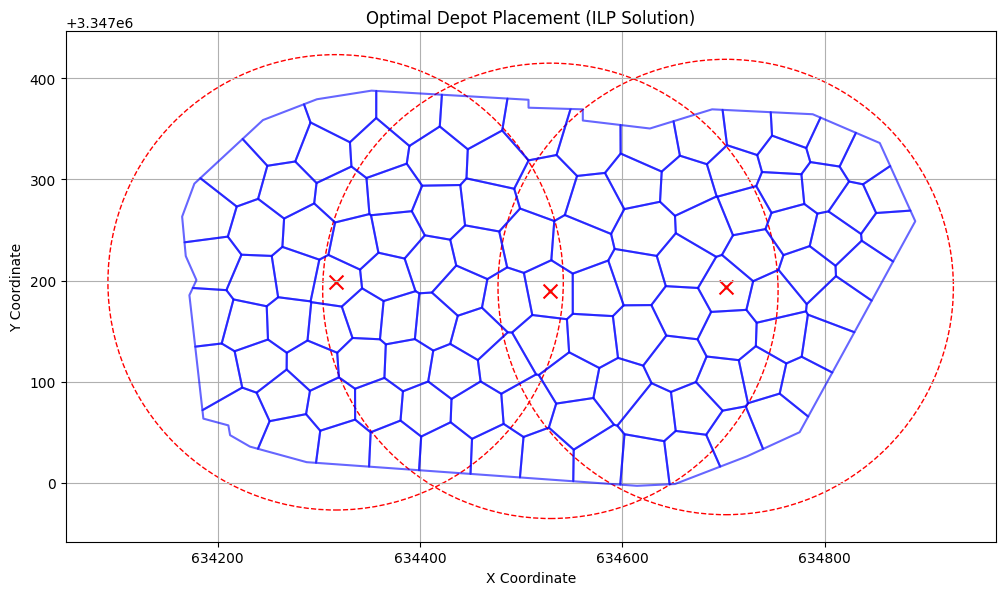

Number of depots placed: 3


In [8]:
import numpy as np
import geopandas as gpd
from shapely.geometry import Point
from pulp import LpProblem, LpVariable, lpSum, LpMinimize, PULP_CBC_CMD, HiGHS_CMD
import matplotlib.pyplot as plt

from macro_planning.depot_placement import find_depots

depot_gdf = find_depots(depot_radius, cell_gdf, region_contour_gdf)


# Visualizations
fig, ax = plt.subplots(figsize=(12, 12))
cell_gdf.boundary.plot(ax=ax, color='blue', alpha=0.6, label='Cell Polygons')

# potential_depots_gdf = gpd.GeoDataFrame({'geometry': [Point(depot.x, depot.y) for depot in potential_depots]})
depot_gdf.plot(ax=ax, color='green', marker='o', label='Potential Depots', markersize=3)


# Plot selected depots and their coverage
for depot in depot_gdf.geometry:
    circle = plt.Circle((depot.x, depot.y), depot_radius, color='red', fill=False, linestyle='--', label='Depot Coverage')
    ax.add_patch(circle)
    ax.scatter(depot.x, depot.y, color='red', marker='x', s=100, label='Depot')

plt.title("Optimal Depot Placement (ILP Solution)")
plt.xlabel("X Coordinate")
plt.ylabel("Y Coordinate")
# plt.legend()
plt.grid(True)
plt.show()

print(f"Number of depots placed: {len(depot_gdf)}")
